Fase inicial de criação e configuração do ambiente para um modelo gernérico, multi-ação.

In [3]:
# ===========================
# Fase 0 — Configurações
# Modelo genérico multi-ação
# ===========================

from pathlib import Path
import os

# ---- Fonte de dados e chaves ----
USE_ALPHA_FIRST = True                            # tenta Alpha Vantage antes do CSV
ALPHAVANTAGE_API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")  # defina no ambiente quando usar Alpha

# ---- Universo de treino (multi-ação) ----
# Misture tickers de mercados diferentes para generalizar padrões.
TICKERS = [
    "AAPL", "MSFT", "AMZN",            # EUA
    "PETR4.SA", "VALE3.SA", "ITUB4.SA" # B3 (usa .SA)
]

START_DATE = "2018-01-01"
END_DATE   = None                      # até hoje

# ---- Janelas e partições ----
LOOKBACK  = 60         # janela temporal
TEST_SIZE = 0.20       # fração para teste (final da série)
VAL_SIZE  = 0.10       # fração para validação (dentro do treino)
RANDOM_SEED = 42

# ---- Treino (ajuste rápido / smoke test) ----
EPOCHS     = 80
BATCH_SIZE = 64

# ---- Estrutura de diretórios (agnóstico ao local de execução) ----
# Se estiver rodando o notebook dentro de "notebook/", ele criará "notebook/data" etc.
ROOT_DIR      = Path.cwd()
DATA_DIR      = ROOT_DIR / "data"
MODELS_DIR    = ROOT_DIR / "models"
ARTIFACTS_DIR = ROOT_DIR / "artifacts"
LOG_DIR       = ROOT_DIR / "logs"

for d in (DATA_DIR, MODELS_DIR, ARTIFACTS_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Nomes de saída (modelo genérico) ----
MODEL_NAME  = "lstm_generic"                       # um único modelo para todos os ativos
MODEL_PATH  = MODELS_DIR / f"{MODEL_NAME}.keras"
SCALER_PATH = ARTIFACTS_DIR / "scaler_generic.joblib"

# ---- Mensagem de contexto ----
print("=== Fase 0: Configurações carregadas ===")
print(f"Fonte preferencial Alpha Vantage: {USE_ALPHA_FIRST} | API_KEY set? {bool(ALPHAVANTAGE_API_KEY)}")
print(f"Tickers (treino multi-ação): {TICKERS}")
print(f"Período: {START_DATE} → {END_DATE or 'hoje'}")
print(f"LOOKBACK={LOOKBACK} | TEST={TEST_SIZE} | VAL={VAL_SIZE} | EPOCHS={EPOCHS} | BATCH_SIZE={BATCH_SIZE}")
print(f"DATA_DIR={DATA_DIR}")
print(f"MODEL_PATH={MODEL_PATH}")
print(f"SCALER_PATH={SCALER_PATH}")


=== Fase 0: Configurações carregadas ===
Fonte preferencial Alpha Vantage: True | API_KEY set? True
Tickers (treino multi-ação): ['AAPL', 'MSFT', 'AMZN', 'PETR4.SA', 'VALE3.SA', 'ITUB4.SA']
Período: 2018-01-01 → hoje
LOOKBACK=60 | TEST=0.2 | VAL=0.1 | EPOCHS=80 | BATCH_SIZE=64
DATA_DIR=d:\Tech\tech4-1\data
MODEL_PATH=d:\Tech\tech4-1\models\lstm_generic.keras
SCALER_PATH=d:\Tech\tech4-1\artifacts\scaler_generic.joblib


Fase 1  - Coleta de dados

In [9]:
# ===========================
# Fase 1 — Coleta & Cache (Alpha → CSV)
# Multi-ação: TICKERS definidos na Fase 0
# ===========================
from alpha_vantage.timeseries import TimeSeries
import pandas as pd
from pathlib import Path
import os

assert 'TICKERS' in globals(), "Defina TICKERS na Fase 0."
assert 'DATA_DIR' in globals(), "Defina DATA_DIR na Fase 0."
assert 'START_DATE' in globals(), "Defina START_DATE na Fase 0."
assert 'USE_ALPHA_FIRST' in globals(), "Defina USE_ALPHA_FIRST na Fase 0."

API_KEY = ALPHAVANTAGE_API_KEY if 'ALPHAVANTAGE_API_KEY' in globals() else os.getenv("ALPHAVANTAGE_API_KEY")

def _csv_path(ticker: str) -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    return DATA_DIR / f"{ticker}.csv"

def _read_local_csv(ticker: str) -> pd.DataFrame | None:
    p = _csv_path(ticker)
    if p.exists():
        df = pd.read_csv(p, parse_dates=["Date"])
        if "Close" not in df.columns:
            raise ValueError(f"CSV local {p} não possui coluna 'Close'.")
        return (df.sort_values("Date")
                  .reset_index(drop=True))
    return None

def _fetch_alpha_to_csv(ticker: str, start_date: str) -> pd.DataFrame:
    """Baixa via Alpha Vantage (se API_KEY existir), converte colunas e salva em CSV (cache)."""
    if not API_KEY:
        raise RuntimeError("ALPHAVANTAGE_API_KEY não definida no ambiente.")
    ts = TimeSeries(key=API_KEY, output_format='pandas')
    # daily, outputsize full (respeite 5 req/min do plano gratuito)
    data, meta = ts.get_daily(symbol=ticker, outputsize='full')
    data = (data.rename(columns={
        '1. open':'Open','2. high':'High','3. low':'Low',
        '4. close':'Close','5. volume':'Volume'
    })
    .reset_index()
    .rename(columns={'date':'Date'}))
    data = data[data['Date'] >= pd.to_datetime(start_date)]
    data = data.sort_values("Date").reset_index(drop=True)

    # Salva no cache local
    path = _csv_path(ticker)
    data.to_csv(path, index=False)
    print(f"[alpha] {ticker}: {len(data)} linhas | salvo em {path}")
    return data

def get_or_fetch(ticker: str, start_date: str) -> pd.DataFrame:
    """Ordem: Alpha (se permitido) → CSV local. Lança erro se nada disponível."""
    # Tenta Alpha primeiro?
    if USE_ALPHA_FIRST:
        try:
            return _fetch_alpha_to_csv(ticker, start_date)
        except Exception as e:
            print(f"[alpha] falhou ({ticker}): {e}. Tentando CSV local…")
            df = _read_local_csv(ticker)
            if df is not None and not df.empty:
                print(f"[csv] usando cache local para {ticker}: {len(df)} linhas")
                return df
            raise

    # Caso contrário, prefira CSV local
    df = _read_local_csv(ticker)
    if df is not None and not df.empty:
        print(f"[csv] usando cache local para {ticker}: {len(df)} linhas")
        return df

    # Último recurso: Alpha
    return _fetch_alpha_to_csv(ticker, start_date)

# ---- Carrega todos os tickers definidos na Fase 0 ----
DATA_BY_TICKER: dict[str, pd.DataFrame] = {}
for t in TICKERS:
    print(f"==> Carregando {t} …")
    df_t = get_or_fetch(t, START_DATE)
    # sanity check mínimo
    cols_min = {"Date","Open","High","Low","Close","Volume"}
    if not cols_min.issubset(set(df_t.columns)):
        raise ValueError(f"{t}: CSV sem colunas mínimas {cols_min}.")
    if df_t["Close"].isna().all():
        raise ValueError(f"{t}: coluna Close vazia.")
    DATA_BY_TICKER[t] = df_t

# ---- Sumário rápido ----
SUMMARY = pd.DataFrame({
    "Ticker": list(DATA_BY_TICKER.keys()),
    "Rows": [len(df) for df in DATA_BY_TICKER.values()],
    "Start": [df["Date"].min() for df in DATA_BY_TICKER.values()],
    "End":   [df["Date"].max() for df in DATA_BY_TICKER.values()],
})
print("\n=== RESUMO DOS DADOS CARREGADOS ===")
display(SUMMARY)


==> Carregando AAPL …
[alpha] AAPL: 1982 linhas | salvo em d:\Tech\tech4-1\data\AAPL.csv
==> Carregando MSFT …
[alpha] AAPL: 1982 linhas | salvo em d:\Tech\tech4-1\data\AAPL.csv
==> Carregando MSFT …
[alpha] MSFT: 1982 linhas | salvo em d:\Tech\tech4-1\data\MSFT.csv
==> Carregando AMZN …
[alpha] MSFT: 1982 linhas | salvo em d:\Tech\tech4-1\data\MSFT.csv
==> Carregando AMZN …
[alpha] AMZN: 1982 linhas | salvo em d:\Tech\tech4-1\data\AMZN.csv
==> Carregando PETR4.SA …
[alpha] AMZN: 1982 linhas | salvo em d:\Tech\tech4-1\data\AMZN.csv
==> Carregando PETR4.SA …
[alpha] PETR4.SA: 1961 linhas | salvo em d:\Tech\tech4-1\data\PETR4.SA.csv
==> Carregando VALE3.SA …
[alpha] PETR4.SA: 1961 linhas | salvo em d:\Tech\tech4-1\data\PETR4.SA.csv
==> Carregando VALE3.SA …
[alpha] VALE3.SA: 1961 linhas | salvo em d:\Tech\tech4-1\data\VALE3.SA.csv
==> Carregando ITUB4.SA …
[alpha] VALE3.SA: 1961 linhas | salvo em d:\Tech\tech4-1\data\VALE3.SA.csv
==> Carregando ITUB4.SA …
[alpha] ITUB4.SA: 1961 linhas | 

,Ticker,Rows,Start,End
0,AAPL,1982,2018-01-02,2025-11-18
1,MSFT,1982,2018-01-02,2025-11-18
2,AMZN,1982,2018-01-02,2025-11-18
3,PETR4.SA,1961,2018-01-02,2025-11-18
4,VALE3.SA,1961,2018-01-02,2025-11-18
5,ITUB4.SA,1961,2018-01-02,2025-11-18


Fase 2 - Preparando o modelo para rodar com várias ações

In [10]:
import numpy as np

# Validações rápidas por ticker — checa presença de colunas, NaNs, duplicatas de Date, volumes negativos e Close não-finitos.
assert 'DATA_BY_TICKER' in globals(), "Execute a Fase 1 antes."

required_cols = globals().get('cols_min', {"Date","Open","High","Low","Close","Volume"})

rows = []
for t, df in DATA_BY_TICKER.items():
    info = {"Ticker": t, "Rows": len(df)}
    # colunas faltantes
    missing_cols = [c for c in required_cols if c not in df.columns]
    info["MissingCols"] = missing_cols
    # contagem de NaNs por coluna (apenas para colunas presentes)
    present_required = [c for c in required_cols if c in df.columns]
    null_counts = df[present_required].isna().sum().to_dict()
    info["NullCounts"] = null_counts
    info["TotalNulls"] = int(df[present_required].isna().sum().sum())
    # Date dtype e duplicatas
    if "Date" in df.columns:
        info["DateDtype"] = str(df["Date"].dtype)
        info["DuplicateDates"] = int(df["Date"].duplicated().sum())
    else:
        info["DateDtype"] = "missing"
        info["DuplicateDates"] = None
    # Volume negativo?
    if "Volume" in df.columns:
        info["AnyNegativeVolume"] = bool((df["Volume"] < 0).any())
    else:
        info["AnyNegativeVolume"] = None
    # Close finite?
    if "Close" in df.columns:
        info["CloseAllFinite"] = bool(np.isfinite(df["Close"]).all())
    else:
        info["CloseAllFinite"] = None
    # regra simples de "tudo OK"
    info["AllGood"] = (
        len(missing_cols) == 0
        and info["TotalNulls"] == 0
        and (info["DuplicateDates"] == 0 or info["DuplicateDates"] is None)
        and (info["AnyNegativeVolume"] is False or info["AnyNegativeVolume"] is None)
        and (info["CloseAllFinite"] is True or info["CloseAllFinite"] is None)
    )
    rows.append(info)

summary_check = pd.DataFrame(rows).set_index("Ticker")
display(summary_check)

# Mostra amostras de problemas (até 5 linhas) para inspeção rápida
for t, df in DATA_BY_TICKER.items():
    problems = []
    if any(c in df.columns and df[c].isna().any() for c in required_cols):
        problems.append("NaNs")
    if "Date" in df.columns and df["Date"].duplicated().any():
        problems.append("DuplicateDates")
    if "Volume" in df.columns and (df["Volume"] < 0).any():
        problems.append("NegativeVolume")
    if "Close" in df.columns and not np.isfinite(df["Close"]).all():
        problems.append("NonFiniteClose")

    if problems:
        print(f"\n==> {t} — problemas detectados: {problems}")
        if df.columns.isin(required_cols).any():
            print("Amostra linhas com NaNs (até 5):")
            display(df[df[required_cols.intersection(df.columns)].isna().any(axis=1)].head(5))
        if "Date" in df.columns and df["Date"].duplicated().any():
            print("Linhas duplicadas por Date (até 5):")
            display(df[df["Date"].duplicated(keep=False)].sort_values("Date").head(5))
        if "Volume" in df.columns and (df["Volume"] < 0).any():
            print("Linhas com Volume negativo (até 5):")
            display(df[df["Volume"] < 0].head(5))
        if "Close" in df.columns and not np.isfinite(df["Close"]).all():
            print("Linhas com Close não-finito (até 5):")
            display(df[~np.isfinite(df["Close"])].head(5))

# Sumariza status final
n_bad = (~summary_check["AllGood"]).sum()
if n_bad == 0:
    print("\n✅ Todas as séries parecem OK (sem colunas faltantes, sem NaNs, sem duplicatas de Date, Close finito, Volume não-negativo).")
else:
    print(f"\n⚠️ {n_bad} ticker(s) com problemas — verifique a saída acima.")

,Rows,MissingCols,NullCounts,TotalNulls,DateDtype,DuplicateDates,AnyNegativeVolume,CloseAllFinite,AllGood
Ticker,,,,,,,,,
AAPL,1982,[],"{'Open': 0, 'Low': 0, 'Volume': 0, 'Close': 0,...",0,datetime64[ns],0,False,True,True
MSFT,1982,[],"{'Open': 0, 'Low': 0, 'Volume': 0, 'Close': 0,...",0,datetime64[ns],0,False,True,True
AMZN,1982,[],"{'Open': 0, 'Low': 0, 'Volume': 0, 'Close': 0,...",0,datetime64[ns],0,False,True,True
PETR4.SA,1961,[],"{'Open': 0, 'Low': 0, 'Volume': 0, 'Close': 0,...",0,datetime64[ns],0,False,True,True
VALE3.SA,1961,[],"{'Open': 0, 'Low': 0, 'Volume': 0, 'Close': 0,...",0,datetime64[ns],0,False,True,True
ITUB4.SA,1961,[],"{'Open': 0, 'Low': 0, 'Volume': 0, 'Close': 0,...",0,datetime64[ns],0,False,True,True



✅ Todas as séries parecem OK (sem colunas faltantes, sem NaNs, sem duplicatas de Date, Close finito, Volume não-negativo).


In [11]:
# ===========================
# Fase 2 — Preparação (multi-ação)
# Normalização global + janelas por ticker + split temporal por ticker
# ===========================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib

assert 'DATA_BY_TICKER' in globals(), "Rode a Fase 1 antes."
assert 'LOOKBACK' in globals(), "Defina LOOKBACK na Fase 0."
assert 'TEST_SIZE' in globals() and 'VAL_SIZE' in globals(), "Defina TEST_SIZE/VAL_SIZE na Fase 0."
assert 'SCALER_PATH' in globals(), "Defina SCALER_PATH na Fase 0."
np.random.seed(RANDOM_SEED)

# 1) Junta os fechamentos de todos os tickers e ajusta o scaler global
all_close = []
for t, df in DATA_BY_TICKER.items():
    s = df[['Date','Close']].copy()
    s['Ticker'] = t
    all_close.append(s)
df_all = pd.concat(all_close, ignore_index=True).sort_values(['Ticker','Date']).reset_index(drop=True)

scaler = MinMaxScaler()
df_all['Close_scaled'] = scaler.fit_transform(df_all[['Close']])

# 2) Funções auxiliares
def make_windowed(series_scaled: np.ndarray, lookback: int):
    """
    Gera janelas X (lookback,1) e alvo y (1,) para uma série já escalada.
    """
    X, y = [], []
    for i in range(lookback, len(series_scaled)):
        X.append(series_scaled[i-lookback:i])
        y.append(series_scaled[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y

def time_series_split_by_fraction(X, y, test_frac: float, val_frac: float):
    """
    Split temporal: [0 .. train | val | test]
    - val_frac é aplicado sobre (train+val)
    """
    n = len(X)
    n_test = int(n * test_frac)
    n_trainval = n - n_test
    n_val = int(n_trainval * val_frac)
    n_train = n_trainval - n_val
    X_train, y_train = X[:n_train], y[:n_train]
    X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
    X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# 3) Gera janelas e splits POR TICKER, depois concatena (evita vazamento entre ativos)
X_tr_list, y_tr_list = [], []
X_va_list, y_va_list = [], []
X_te_list, y_te_list = [], []

for t in sorted(DATA_BY_TICKER.keys()):
    sub = df_all.loc[df_all['Ticker'] == t].sort_values('Date').reset_index(drop=True)
    series = sub['Close_scaled'].values
    if len(series) <= LOOKBACK + 10:
        print(f"[aviso] Série muito curta para {t} (len={len(series)}). Pulando.")
        continue

    X_t, y_t = make_windowed(series, lookback=LOOKBACK)
    (X_tr, y_tr), (X_va, y_va), (X_te, y_te) = time_series_split_by_fraction(
        X_t, y_t, test_frac=TEST_SIZE, val_frac=VAL_SIZE
    )

    X_tr_list.append(X_tr); y_tr_list.append(y_tr)
    X_va_list.append(X_va); y_va_list.append(y_va)
    X_te_list.append(X_te); y_te_list.append(y_te)

# 4) Concatena tudo para treinar um único modelo genérico
def _cat(xs): 
    return np.concatenate(xs, axis=0) if len(xs) else np.empty((0, LOOKBACK, 1))
def _cat_y(ys): 
    return np.concatenate(ys, axis=0) if len(ys) else np.empty((0, 1))

X_train, y_train = _cat(X_tr_list), _cat_y(y_tr_list)
X_val,   y_val   = _cat(X_va_list), _cat_y(y_va_list)
X_test,  y_test  = _cat(X_te_list), _cat_y(y_te_list)

print("=== Shapes finais (concat por ticker) ===")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

# 5) Persiste o scaler global (compatível com a API atual)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, SCALER_PATH)
print(f"Scaler salvo em: {SCALER_PATH}")


=== Shapes finais (concat por ticker) ===
X_train: (8262, 60, 1) | y_train: (8262, 1)
X_val:   (915, 60, 1) | y_val:   (915, 1)
X_test:  (2292, 60, 1) | y_test:  (2292, 1)
Scaler salvo em: d:\Tech\tech4-1\artifacts\scaler_generic.joblib


In [ ]:
# Callback para métricas em unidades originais (preço) por época — usa amostra para não ficar lento
from tensorflow.keras.callbacks import Callback
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

class OrigScaleMetrics(Callback):
    def __init__(self, X_train, y_train, X_val, y_val, scaler, sample_size=1024, every_n_epochs=1):
        super().__init__()
        # mantém apenas uma amostra para cada conjunto (evita custo alto por época)
        self.X_train = X_train[:sample_size]
        self.y_train = y_train[:sample_size]
        self.X_val = X_val[:sample_size]
        self.y_val = y_val[:sample_size]
        self.scaler = scaler
        self.every = every_n_epochs
        self.train_mae = []
        self.val_mae = []
        self.train_rmse = []
        self.val_rmse = []

    def _to_orig(self, y_scaled):
        arr = np.asarray(y_scaled).reshape(-1, 1)
        return self.scaler.inverse_transform(arr).reshape(-1)

    def on_epoch_end(self, epoch, logs=None):
        # registra a cada `every` épocas
        if (epoch + 1) % self.every != 0:
            return
        try:
            yp_train = self.model.predict(self.X_train, verbose=0)
            yp_val = self.model.predict(self.X_val, verbose=0)
            ytr_orig = self._to_orig(self.y_train)
            ypv_orig = self._to_orig(yp_train)
            yv_orig = self._to_orig(self.y_val)
            ypv_val_orig = self._to_orig(yp_val)

            train_mae = mean_absolute_error(ytr_orig, ypv_orig)
            val_mae = mean_absolute_error(yv_orig, ypv_val_orig)
            train_rmse = mean_squared_error(ytr_orig, ypv_orig, squared=False)
            val_rmse = mean_squared_error(yv_orig, ypv_val_orig, squared=False)

            self.train_mae.append(train_mae)
            self.val_mae.append(val_mae)
            self.train_rmse.append(train_rmse)
            self.val_rmse.append(val_rmse)

            # opcional: coloca no logs para aparecer em `history.history` se desejar
            if logs is not None:
                logs['train_mae_orig'] = train_mae
                logs['val_mae_orig'] = val_mae
        except Exception as e:
            print('OrigScaleMetrics erro:', e)

# instância do callback (usa tamanho de amostra controlado)
orig_cb = OrigScaleMetrics(X_train, y_train, X_val, y_val, scaler, sample_size=1024, every_n_epochs=1)


Fase 3 - Modelagem e treino

In [ ]:
# ===========================
# Fase 3 — Modelagem & Treino
# ===========================
import os
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import Huber

assert 'X_train' in globals() and 'y_train' in globals(), "Rode a Fase 2 antes."
assert X_train.shape[1] == LOOKBACK and X_train.shape[2] == 1, "Shape inesperado para X_train."

def build_lstm_model(lookback: int = 60):
    model = Sequential([
        LSTM(96, return_sequences=True, input_shape=(lookback, 1), recurrent_dropout=0.1),
        LayerNormalization(),
        Dropout(0.2),
        LSTM(64, recurrent_dropout=0.1),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss=Huber(delta=1.0))  # mais robusto que MSE
    return model

model = build_lstm_model(LOOKBACK)
model.summary()

# Callbacks
ckpt_path = str(MODEL_PATH.with_name(f"{MODEL_PATH.stem}_ckpt.keras"))
es  = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=31, min_lr=1e-5, verbose=1)
ckp = ModelCheckpoint(filepath=ckpt_path, monitor="val_loss", save_best_only=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr, ckp, orig_cb],
    verbose=1,
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 96)            37632     
                                                                 
 layer_normalization (LayerN  (None, 60, 96)           192       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 60, 96)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                41216     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 79,105
Trainable params: 79,105
Non-trainable params: 0
____________________________________________________

In [12]:
# DEBUG: checagem rápida de shapes e consistência antes da avaliação
import numpy as np
import os
import pandas as pd

def _report_arr(name, arr):
    try:
        a = np.asarray(arr)
        info = {
            'shape': getattr(a, 'shape', None),
            'ndim': getattr(a, 'ndim', None),
            'dtype': str(getattr(a, 'dtype', None)),
        }
        print(f"{name}: shape={info['shape']}, ndim={info['ndim']}, dtype={info['dtype']}")
        # NaN/Inf checks for numeric arrays
        if np.issubdtype(a.dtype, np.number):
            print(f"  any_nan={np.isnan(a).any()}, any_inf={np.isinf(a).any()}")
    except Exception as e:
        print(f"{name}: erro ao inspecionar -> {e}")

print('\n=== Relatório rápido de consistência ===')
for var in ['X_train','y_train','X_val','y_val','X_test','y_test','df_all','scaler']:
    if var in globals():
        _report_arr(var, globals().get(var))
    else:
        print(f"{var}: NÃO DEFINIDO")

# Checa capacidade de predição do modelo (previsão de amostra)
try:
    if 'model' in globals() and 'X_test' in globals() and getattr(X_test, 'shape', (0,))[0] > 0:
        pred_shape = model.predict(X_test[:1]).shape
        print(f"model.predict(sample) -> shape: {pred_shape}")
    else:
        print('model ou X_test indisponível para predict de teste')
except Exception as e:
    print('model.predict disparou erro:', e)

# Scaler / paths
try:
    print('SCALER_PATH:', SCALER_PATH)
    print('scaler variable is object:', type(globals().get('scaler')))
    print('scaler file exists on disk:', os.path.exists(str(SCALER_PATH)))
except Exception as e:
    print('Erro ao checar SCALER_PATH:', e)

# Mostra resumo de NaNs no df_all (se existir)
if 'df_all' in globals():
    try:
        print('\nResumo de NaNs em df_all (por coluna):')
        print(df_all.isna().sum().to_dict())
    except Exception as e:
        print('Erro ao resumir df_all:', e)

print('\n=== Fim do relatório ===\n')



=== Relatório rápido de consistência ===
X_train: shape=(8262, 60, 1), ndim=3, dtype=float64
  any_nan=False, any_inf=False
y_train: shape=(8262, 1), ndim=2, dtype=float64
  any_nan=False, any_inf=False
X_val: shape=(915, 60, 1), ndim=3, dtype=float64
  any_nan=False, any_inf=False
y_val: shape=(915, 1), ndim=2, dtype=float64
  any_nan=False, any_inf=False
X_test: shape=(2292, 60, 1), ndim=3, dtype=float64
  any_nan=False, any_inf=False
y_test: shape=(2292, 1), ndim=2, dtype=float64
  any_nan=False, any_inf=False
df_all: shape=(11829, 4), ndim=2, dtype=object
scaler: shape=(), ndim=0, dtype=object
1/1 [==============================] - 0s 30ms/step
model.predict(sample) -> shape: (1, 1)
SCALER_PATH: d:\Tech\tech4-1\artifacts\scaler_generic.joblib
scaler variable is object: <class 'sklearn.preprocessing._data.MinMaxScaler'>
scaler file exists on disk: True

Resumo de NaNs em df_all (por coluna):
{'Date': 0, 'Close': 0, 'Ticker': 0, 'Close_scaled': 0}

=== Fim do relatório ===

1/1 [===

Fase 4 - Avaliação e Salvamento

Debug shapes -> y_test: (2292, 1), yhat_scaled: (2292, 1)
MAE : 4.4518
RMSE: 6.4315
MAPE: 3.45%


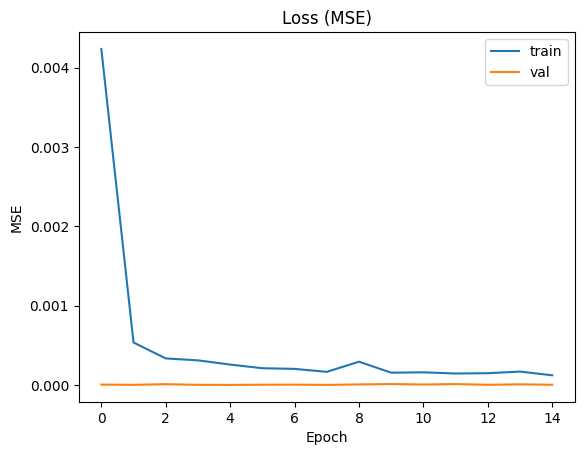

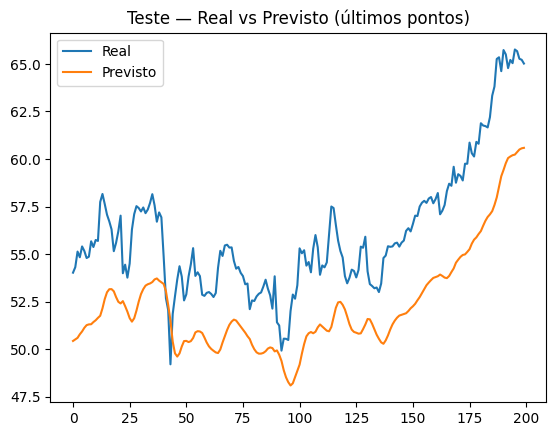

✅ Modelo salvo em: d:\Tech\tech4-1\models\lstm_generic.keras
✅ Scaler salvo em: d:\Tech\tech4-1\artifacts\scaler_generic.joblib
ℹ️ Lembrete para API: LOOKBACK=60


In [13]:
# ===========================
# Fase 4 — Avaliação & Salvamento (robusto)
# ===========================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib

# Garantias mínimas
if 'X_test' not in globals() or X_test is None or len(X_test) == 0:
    print("⚠️ Conjunto de teste vazio — não há nada para avaliar. Execute as fases anteriores e verifique os dados.")
else:
    # Previsões (em escala)
    yhat_test_scaled = model.predict(X_test, verbose=0)

    # Garantir que y_test e yhat_test_scaled sejam arrays numpy
    y_test_arr = np.asarray(y_test)
    yhat_scaled_arr = np.asarray(yhat_test_scaled)

    print(f"Debug shapes -> y_test: {y_test_arr.shape}, yhat_scaled: {yhat_scaled_arr.shape}")

    # Scaler espera entrada 2D (n_samples, n_features)
    try:
        # Se for 1D, transformar para (n,1)
        if y_test_arr.ndim == 1:
            y_test_for_inv = y_test_arr.reshape(-1, 1)
        else:
            y_test_for_inv = y_test_arr

        if yhat_scaled_arr.ndim == 1:
            yhat_for_inv = yhat_scaled_arr.reshape(-1, 1)
        else:
            yhat_for_inv = yhat_scaled_arr

        # Inverte a escala usando o mesmo scaler usado no treino
        y_test_inv  = scaler.inverse_transform(y_test_for_inv)
        yhat_test_inv = scaler.inverse_transform(yhat_for_inv)
    except Exception as e:
        # Caso o inverse_transform falhe, mostramos debug e tentamos uma alternativa segura
        print("Erro ao aplicar inverse_transform no scaler:", e)
        # Última tentativa: forçar reshape compatível e reexecutar
        try:
            y_test_inv = scaler.inverse_transform(y_test_arr.reshape(-1, 1))
            yhat_test_inv = scaler.inverse_transform(yhat_scaled_arr.reshape(-1, 1))
        except Exception as e2:
            raise RuntimeError(f"Falha persistente ao desserializar previsões: {e2}")

    # Flatten para métricas/plots (1D sequences)
    y_test_flat = np.asarray(y_test_inv).reshape(-1)
    yhat_flat = np.asarray(yhat_test_inv).reshape(-1)

    # Verifica alinhamento de comprimento
    if y_test_flat.shape[0] != yhat_flat.shape[0]:
        # Tenta truncar ao menor tamanho com aviso
        nmin = min(y_test_flat.shape[0], yhat_flat.shape[0])
        print(f"⚠️ Comprimentos diferentes (y_test={y_test_flat.shape[0]}, yhat={yhat_flat.shape[0]}). Truncando para {nmin} antes de calcular métricas.")
        y_test_flat = y_test_flat[:nmin]
        yhat_flat = yhat_flat[:nmin]

    # Calcular métricas
    mae  = mean_absolute_error(y_test_flat, yhat_flat)
    rmse = mean_squared_error(y_test_flat, yhat_flat, squared=False)
    mape = float(np.mean(np.abs((y_test_flat - yhat_flat) / (y_test_flat + 1e-8))) * 100)

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")

    # Curva de perda (se existir history)
    try:
        plt.figure()
        plt.plot(history.history["loss"], label="train")
        plt.plot(history.history["val_loss"], label="val")
        plt.title("Loss (MSE)")
        plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()
    except Exception:
        print("⚠️ Histórico de treino (`history`) não disponível para plot de perda.")

    # Real vs. Previsto (últimos 200 pontos do teste, se houver)
    tail = min(200, len(y_test_flat))
    if tail > 0:
        plt.figure()
        plt.plot(y_test_flat[-tail:], label="Real")
        plt.plot(yhat_flat[-tail:], label="Previsto")
        plt.title("Teste — Real vs Previsto (últimos pontos)")
        plt.legend(); plt.show()

    # Salvamento do modelo e confirmação do scaler (para uso na API)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    model.save(MODEL_PATH)
    joblib.dump(scaler, SCALER_PATH)

    print(f"✅ Modelo salvo em: {MODEL_PATH}")
    print(f"✅ Scaler salvo em: {SCALER_PATH}")
    print(f"ℹ️ Lembrete para API: LOOKBACK={LOOKBACK}")
